In [6]:
# ============================================================
# Get Fit with Drishti
# Phase 5 Part B: Win-Back Playbook
# Step 1: Load data and create corrected dropout analysis table
# ============================================================

# Import pandas to read and work with the dataset
import pandas as pd

# Import numpy for simple conditional logic
import numpy as np


# ------------------------------------------------------------
# 1. Load the cleaned dataset
# ------------------------------------------------------------

# Load the cleaned data from the cleaned data folder
df = pd.read_csv("../02_cleaned_data/Drishti_Clean_Data.csv")

# Show the dataset size to confirm it loaded correctly
print("Dataset shape:")
print(df.shape)


# ------------------------------------------------------------
# 2. Select the dropout-related columns we need
# ------------------------------------------------------------

# These columns will be used for the win-back playbook analysis
dropout_columns = [
    "Client_ID",
    "Status",
    "Dropout_Day",
    "Dropout_Reason",
    "Returned_After_Drop",
    "Weeks_Before_Return",
    "Return_Trigger",
    "Goal_Achieved"
]

# Check missing values in these columns before analysis
print("\nMissing values in dropout-related columns:")
print(df[dropout_columns].isnull().sum())


# ------------------------------------------------------------
# 3. Create the correct dropout-only table
# ------------------------------------------------------------

# A true dropout client has Returned_After_Drop as either "Yes" or "No"
# Non-dropout clients do not have a real return status
dropout_df = df[df["Returned_After_Drop"].isin(["Yes", "No"])].copy()

# Show how many true dropout clients exist
print("\nCorrect total dropout clients:")
print(len(dropout_df))


# ------------------------------------------------------------
# 4. Create a return flag
# ------------------------------------------------------------

# 1 = client returned after dropping
# 0 = client did not return after dropping
dropout_df["Returned_Flag"] = np.where(
    dropout_df["Returned_After_Drop"] == "Yes",
    1,
    0
)


# ------------------------------------------------------------
# 5. Count returned vs not returned clients
# ------------------------------------------------------------

# Count how many dropout clients returned and did not return
print("\nReturned after drop counts:")
print(dropout_df["Returned_After_Drop"].value_counts())


# ------------------------------------------------------------
# 6. Calculate the correct win-back rate
# ------------------------------------------------------------

# Win-back rate = returned dropout clients / total dropout clients
winback_rate = dropout_df["Returned_Flag"].mean() * 100

print("\nCorrect win-back rate:")
print(round(winback_rate, 2), "%")


# ------------------------------------------------------------
# 7. Check missing values inside the corrected dropout table
# ------------------------------------------------------------

# This checks only the true dropout clients
print("\nMissing values inside corrected dropout table:")
print(dropout_df[dropout_columns].isnull().sum())


# ------------------------------------------------------------
# 8. Preview the corrected dropout table
# ------------------------------------------------------------

# Show the first few rows of the dropout-only table
dropout_df[
    [
        "Client_ID",
        "Status",
        "Dropout_Day",
        "Dropout_Reason",
        "Returned_After_Drop",
        "Weeks_Before_Return",
        "Return_Trigger",
        "Goal_Achieved",
        "Returned_Flag"
    ]
].head()

Dataset shape:
(3000, 40)

Missing values in dropout-related columns:
Client_ID                 0
Status                    0
Dropout_Day               0
Dropout_Reason         2930
Returned_After_Drop    2677
Weeks_Before_Return       0
Return_Trigger         2770
Goal_Achieved             0
dtype: int64

Correct total dropout clients:
323

Returned after drop counts:
Returned_After_Drop
Yes    230
No      93
Name: count, dtype: int64

Correct win-back rate:
71.21 %

Missing values inside corrected dropout table:
Client_ID                0
Status                   0
Dropout_Day              0
Dropout_Reason         253
Returned_After_Drop      0
Weeks_Before_Return      0
Return_Trigger          93
Goal_Achieved            0
dtype: int64


,Client_ID,Status,Dropout_Day,Dropout_Reason,Returned_After_Drop,Weeks_Before_Return,Return_Trigger,Goal_Achieved,Returned_Flag
1,C0002,Ghost,5.0,NaN,No,0.0,NaN,No,0
4,C0005,Ghost,4.0,NaN,Yes,11.0,Saw Other Clients Progress,No,1
6,C0007,Ghost,1.0,NaN,No,0.0,NaN,No,0
10,C0011,Ghost,6.0,NaN,Yes,19.0,Saw Other Clients Progress,No,1
15,C0016,Ghost,5.0,NaN,No,0.0,NaN,No,0


Total returned clients:
230

Return trigger breakdown:
               Return_Trigger  Client_Count  Percentage
0  Saw Other Clients Progress           179       77.83
1   Personal Motivation Reset            51       22.17


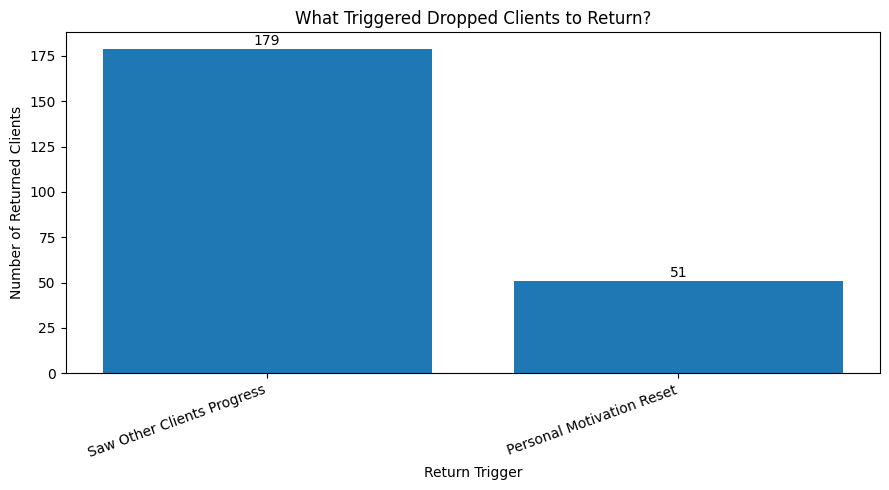

In [7]:
# ============================================================
# Phase 5 Part B
# Step 2: Analyze return triggers
# ============================================================

# ------------------------------------------------------------
# 1. Create a table with only clients who returned after dropping
# ------------------------------------------------------------

# Keep only dropout clients who came back
returned_df = dropout_df[dropout_df["Returned_After_Drop"] == "Yes"].copy()

# Show how many returned clients we have
print("Total returned clients:")
print(len(returned_df))


# ------------------------------------------------------------
# 2. Count each return trigger
# ------------------------------------------------------------

# Count how many clients returned because of each trigger
return_trigger_counts = (
    returned_df["Return_Trigger"]
    .value_counts()
    .reset_index()
)

# Rename columns clearly
return_trigger_counts.columns = ["Return_Trigger", "Client_Count"]

# Add percentage of returned clients
return_trigger_counts["Percentage"] = (
    return_trigger_counts["Client_Count"] / len(returned_df) * 100
).round(2)

# Show the final return trigger table
print("\nReturn trigger breakdown:")
print(return_trigger_counts)


# ------------------------------------------------------------
# 3. Create a simple bar chart
# ------------------------------------------------------------

# Import matplotlib for charting
import matplotlib.pyplot as plt

# Create chart
plt.figure(figsize=(9, 5))

plt.bar(
    return_trigger_counts["Return_Trigger"],
    return_trigger_counts["Client_Count"]
)

# Add chart title and labels
plt.title("What Triggered Dropped Clients to Return?")
plt.xlabel("Return Trigger")
plt.ylabel("Number of Returned Clients")

# Rotate x-axis labels so they are easy to read
plt.xticks(rotation=20, ha="right")

# Add count labels on top of bars
for index, value in enumerate(return_trigger_counts["Client_Count"]):
    plt.text(index, value + 2, str(value), ha="center")

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

Weeks before return summary:
count    230.000000
mean       8.547826
std        6.784575
min        1.000000
25%        3.000000
50%        7.000000
75%       12.000000
max       24.000000
Name: Weeks_Before_Return, dtype: float64

Return timing metrics:
Average weeks before return: 8.55
Median weeks before return: 7.0
Most common return week: 4.0

Week-by-week return distribution:
    Weeks_Before_Return  Returned_Client_Count  Percentage
0                   1.0                     23       10.00
1                   2.0                     22        9.57
2                   3.0                     23       10.00
3                   4.0                     32       13.91
4                   5.0                      8        3.48
5                   6.0                      4        1.74
6                   7.0                     10        4.35
7                   8.0                      9        3.91
8                   9.0                     15        6.52
9                  10.0  

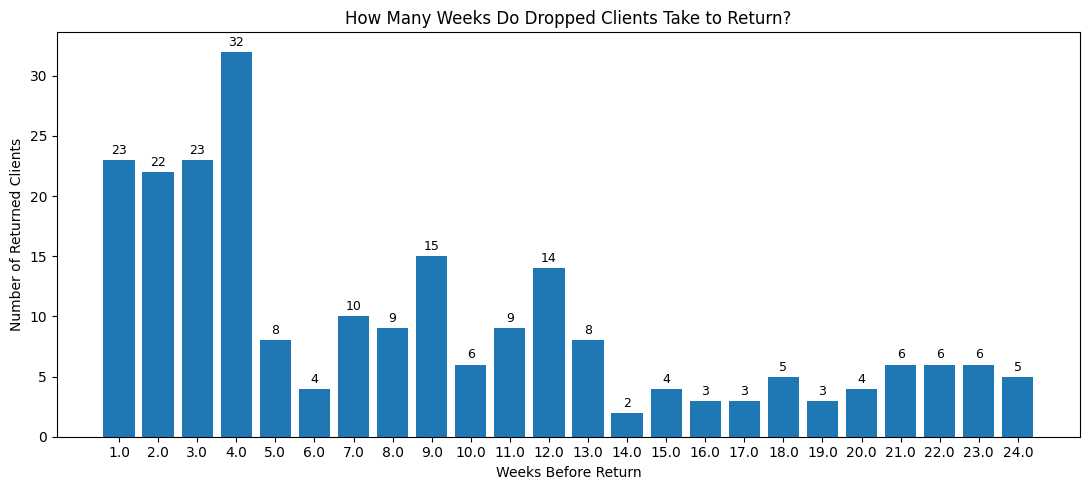

In [8]:
# ============================================================
# Phase 5 Part B
# Step 3: Analyze weeks before return
# ============================================================

# ------------------------------------------------------------
# 1. Check basic statistics for Weeks_Before_Return
# ------------------------------------------------------------

# Only returned clients have a meaningful Weeks_Before_Return value
weeks_return_summary = returned_df["Weeks_Before_Return"].describe()

print("Weeks before return summary:")
print(weeks_return_summary)


# ------------------------------------------------------------
# 2. Calculate key business-friendly return timing metrics
# ------------------------------------------------------------

# Average weeks before return
avg_weeks_before_return = returned_df["Weeks_Before_Return"].mean()

# Median weeks before return
median_weeks_before_return = returned_df["Weeks_Before_Return"].median()

# Most common return week
mode_weeks_before_return = returned_df["Weeks_Before_Return"].mode()[0]

print("\nReturn timing metrics:")
print("Average weeks before return:", round(avg_weeks_before_return, 2))
print("Median weeks before return:", round(median_weeks_before_return, 2))
print("Most common return week:", mode_weeks_before_return)


# ------------------------------------------------------------
# 3. Create week-by-week return distribution table
# ------------------------------------------------------------

# Count how many clients returned in each week
weeks_return_distribution = (
    returned_df["Weeks_Before_Return"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns clearly
weeks_return_distribution.columns = ["Weeks_Before_Return", "Returned_Client_Count"]

# Add percentage of total returned clients
weeks_return_distribution["Percentage"] = (
    weeks_return_distribution["Returned_Client_Count"] / len(returned_df) * 100
).round(2)

print("\nWeek-by-week return distribution:")
print(weeks_return_distribution)


# ------------------------------------------------------------
# 4. Create a bar chart for return timing
# ------------------------------------------------------------

# Create chart
plt.figure(figsize=(11, 5))

plt.bar(
    weeks_return_distribution["Weeks_Before_Return"].astype(str),
    weeks_return_distribution["Returned_Client_Count"]
)

# Add chart title and labels
plt.title("How Many Weeks Do Dropped Clients Take to Return?")
plt.xlabel("Weeks Before Return")
plt.ylabel("Number of Returned Clients")

# Add count labels on top of bars
for index, value in enumerate(weeks_return_distribution["Returned_Client_Count"]):
    plt.text(index, value + 0.5, str(value), ha="center", fontsize=9)

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

Returning clients:
230

Never-dropped clients:
2677

Goal success comparison:
Returning clients success rate: 0.0 %
Never-dropped clients success rate: 90.81 %

Goal achievement breakdown comparison:
  Goal_Achieved  Returning_Client_Percentage  Never_Dropped_Client_Percentage
0            No                        100.0                             0.00
1       Ongoing                          0.0                             9.19
2       Partial                          0.0                            33.43
3           Yes                          0.0                            57.38


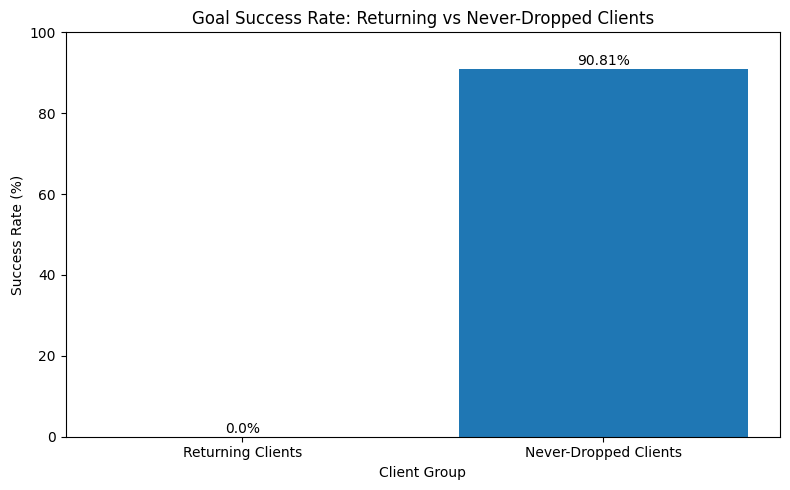

In [9]:
# ============================================================
# Phase 5 Part B
# Step 4: Compare goal achievement of returning clients vs never-dropped clients
# ============================================================

# ------------------------------------------------------------
# 1. Create client groups for comparison
# ------------------------------------------------------------

# Returning clients = clients who dropped out and came back
returning_clients = df[df["Returned_After_Drop"] == "Yes"].copy()

# Never-dropped clients = clients who do not have Yes or No in Returned_After_Drop
# These are clients who never entered the dropout-return cycle
never_dropped_clients = df[~df["Returned_After_Drop"].isin(["Yes", "No"])].copy()

# Print group sizes
print("Returning clients:")
print(len(returning_clients))

print("\nNever-dropped clients:")
print(len(never_dropped_clients))


# ------------------------------------------------------------
# 2. Add a clean success flag
# ------------------------------------------------------------

# Success means the client achieved their goal fully or partially
# This is more realistic than using only "Yes"
returning_clients["Success_Flag"] = np.where(
    returning_clients["Goal_Achieved"].isin(["Yes", "Partial"]),
    1,
    0
)

never_dropped_clients["Success_Flag"] = np.where(
    never_dropped_clients["Goal_Achieved"].isin(["Yes", "Partial"]),
    1,
    0
)


# ------------------------------------------------------------
# 3. Calculate success rates
# ------------------------------------------------------------

# Success rate for returning clients
returning_success_rate = returning_clients["Success_Flag"].mean() * 100

# Success rate for never-dropped clients
never_dropped_success_rate = never_dropped_clients["Success_Flag"].mean() * 100

print("\nGoal success comparison:")
print("Returning clients success rate:", round(returning_success_rate, 2), "%")
print("Never-dropped clients success rate:", round(never_dropped_success_rate, 2), "%")


# ------------------------------------------------------------
# 4. Create goal achievement breakdown table
# ------------------------------------------------------------

# Count Goal_Achieved values for returning clients
returning_goal_breakdown = (
    returning_clients["Goal_Achieved"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

returning_goal_breakdown.columns = ["Goal_Achieved", "Returning_Client_Percentage"]

# Count Goal_Achieved values for never-dropped clients
never_dropped_goal_breakdown = (
    never_dropped_clients["Goal_Achieved"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

never_dropped_goal_breakdown.columns = ["Goal_Achieved", "Never_Dropped_Client_Percentage"]

# Merge both tables for easy comparison
goal_comparison_table = pd.merge(
    returning_goal_breakdown,
    never_dropped_goal_breakdown,
    on="Goal_Achieved",
    how="outer"
).fillna(0)

print("\nGoal achievement breakdown comparison:")
print(goal_comparison_table)


# ------------------------------------------------------------
# 5. Create a simple comparison bar chart
# ------------------------------------------------------------

# Prepare chart data
success_chart_df = pd.DataFrame({
    "Client_Group": ["Returning Clients", "Never-Dropped Clients"],
    "Success_Rate": [returning_success_rate, never_dropped_success_rate]
})

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    success_chart_df["Client_Group"],
    success_chart_df["Success_Rate"]
)

# Add title and labels
plt.title("Goal Success Rate: Returning vs Never-Dropped Clients")
plt.xlabel("Client Group")
plt.ylabel("Success Rate (%)")

# Add percentage labels on top of bars
for index, value in enumerate(success_chart_df["Success_Rate"]):
    plt.text(index, value + 1, str(round(value, 2)) + "%", ha="center")

# Keep y-axis from 0 to 100
plt.ylim(0, 100)

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

In [10]:
# ============================================================
# Phase 5 Part B
# Step 4 Validation: Check returning clients' goal outcomes
# ============================================================

# Check Goal_Achieved values for returned clients
print("Goal_Achieved breakdown for returned clients:")
print(returning_clients["Goal_Achieved"].value_counts(dropna=False))

# Check Goal_Achieved values for non-returned dropout clients
non_returned_clients = df[df["Returned_After_Drop"] == "No"].copy()

print("\nGoal_Achieved breakdown for non-returned dropout clients:")
print(non_returned_clients["Goal_Achieved"].value_counts(dropna=False))

# Check Goal_Achieved values for never-dropped clients
print("\nGoal_Achieved breakdown for never-dropped clients:")
print(never_dropped_clients["Goal_Achieved"].value_counts(dropna=False))

# Create a full comparison table
goal_validation_table = pd.crosstab(
    df["Returned_After_Drop"].fillna("Never Dropped"),
    df["Goal_Achieved"],
    margins=True
)

print("\nFull Goal_Achieved comparison table:")
print(goal_validation_table)

Goal_Achieved breakdown for returned clients:
Goal_Achieved
No    230
Name: count, dtype: int64

Goal_Achieved breakdown for non-returned dropout clients:
Goal_Achieved
No    93
Name: count, dtype: int64

Goal_Achieved breakdown for never-dropped clients:
Goal_Achieved
Yes        1536
Partial     895
Ongoing     246
Name: count, dtype: int64

Full Goal_Achieved comparison table:
Goal_Achieved         No  Ongoing  Partial   Yes   All
Returned_After_Drop                                   
Never Dropped          0      246      895  1536  2677
No                    93        0        0     0    93
Yes                  230        0        0     0   230
All                  323      246      895  1536  3000


Dropout clients with known reason:
70

Dropout clients with missing reason:
253

Win-back rate by dropout reason:
  Dropout_Reason  Total_Dropouts  Returned_Clients  Winback_Rate_Pct  \
1   Health Issue               7                 7            100.00   
0  Busy Schedule              41                32             78.05   
2       Laziness              22                14             63.64   

   Did_Not_Return  
1               0  
0               9  
2               8  


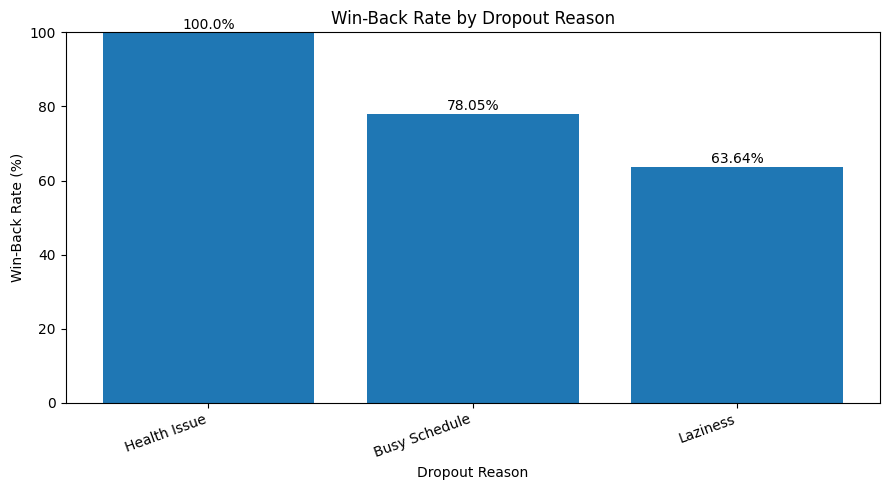

In [11]:
# ============================================================
# Phase 5 Part B
# Step 5: Analyze win-back rate by dropout reason
# ============================================================

# ------------------------------------------------------------
# 1. Keep only dropout clients with a known dropout reason
# ------------------------------------------------------------

# Some dropout clients do not have a recorded dropout reason
# For this analysis, we only use rows where Dropout_Reason is available
dropout_reason_df = dropout_df[dropout_df["Dropout_Reason"].notnull()].copy()

# Show how many dropout clients have a known reason
print("Dropout clients with known reason:")
print(len(dropout_reason_df))

# Show how many dropout clients have missing reason
print("\nDropout clients with missing reason:")
print(dropout_df["Dropout_Reason"].isnull().sum())


# ------------------------------------------------------------
# 2. Calculate win-back rate by dropout reason
# ------------------------------------------------------------

# Group by dropout reason and calculate total clients, returned clients, and win-back rate
reason_winback_table = (
    dropout_reason_df
    .groupby("Dropout_Reason")
    .agg(
        Total_Dropouts=("Client_ID", "count"),
        Returned_Clients=("Returned_Flag", "sum")
    )
    .reset_index()
)

# Calculate win-back rate for each dropout reason
reason_winback_table["Winback_Rate_Pct"] = (
    reason_winback_table["Returned_Clients"] / reason_winback_table["Total_Dropouts"] * 100
).round(2)

# Calculate clients who did not return
reason_winback_table["Did_Not_Return"] = (
    reason_winback_table["Total_Dropouts"] - reason_winback_table["Returned_Clients"]
)

# Sort from highest win-back rate to lowest
reason_winback_table = reason_winback_table.sort_values(
    by="Winback_Rate_Pct",
    ascending=False
)

print("\nWin-back rate by dropout reason:")
print(reason_winback_table)


# ------------------------------------------------------------
# 3. Create a simple bar chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    reason_winback_table["Dropout_Reason"],
    reason_winback_table["Winback_Rate_Pct"]
)

# Add title and labels
plt.title("Win-Back Rate by Dropout Reason")
plt.xlabel("Dropout Reason")
plt.ylabel("Win-Back Rate (%)")

# Add percentage labels on top of bars
for index, value in enumerate(reason_winback_table["Winback_Rate_Pct"]):
    plt.text(index, value + 1, str(value) + "%", ha="center")

# Keep y-axis from 0 to 100
plt.ylim(0, 100)

# Rotate labels if needed
plt.xticks(rotation=20, ha="right")

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()